In [32]:
!pip install numpy torchtext scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.0 MB 11.9 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 12.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.3 MB 12.2 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/36.3 MB 12.3 MB/s eta 0:00:03
   -------- ------------------------------- 7.6/36.3 MB 12.3 MB/s eta 0:00:03
   ---------- ----------------------------- 10.0/36.3 MB 12.3 MB/s eta 0:00:03
   ------------- -------------------------- 12.6/36.3 MB 12.0 MB/s eta 0:00:02
   ---------------- ----------------------- 14.9/36.3 MB 12.1 MB/s eta 0:00:02
   ----------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:

import torchtext

# 1. Scarichiamo i vettori GloVe (versione 6B, 100 dimensioni)
print("Scaricando GloVe...")
glove = torchtext.vocab.GloVe(name='6B', dim=100) # ATTENZIONE è CASE INSENSITIVE, LE PAROLE VANNO RESE MINUSCOLE

Scaricando GloVe...


In [39]:
glove['roma']

tensor([ 0.9902,  0.1263, -0.4120, -0.1269, -0.6551,  1.3646,  0.5795,  0.0244,
         0.1194,  0.0756,  0.0176, -0.5177, -0.8328,  0.0342, -0.1077,  0.2197,
         0.1427, -0.5625,  0.1221,  1.1290, -0.1753,  0.1045,  0.3912,  1.5320,
         0.4952, -1.4230,  0.3517,  0.0733, -0.2967, -0.7602, -0.9920,  0.3318,
        -0.4372,  0.7264,  0.5686, -0.2720,  0.8550,  1.0131, -0.2644,  0.3534,
        -0.5115, -0.3765,  0.5333, -0.1973,  0.8893, -0.1567,  0.0629,  0.4103,
         0.2120,  0.6559,  0.2454, -0.0417, -1.4066,  0.7826, -0.8564, -1.2949,
        -0.6008,  0.3038,  0.2005,  0.1570, -0.3246,  0.1584, -0.7013, -0.5154,
         0.2990,  0.6125,  0.0673,  0.0058,  0.1541, -0.6095, -0.0686, -0.2263,
         0.1221, -0.5967,  0.4479, -0.6651, -1.1599,  0.3908, -0.0393,  0.1283,
         0.1296, -0.5808, -0.9760,  0.1922, -0.8208, -0.6466, -1.1368,  1.0863,
        -0.1426, -0.0443, -0.9639, -0.1249,  0.2720,  0.5261, -0.2385, -0.5530,
        -0.0221,  1.1593, -0.1618,  0.01

In [40]:
glove.stoi

{'the': 0,
 ',': 1,
 '.': 2,
 'of': 3,
 'to': 4,
 'and': 5,
 'in': 6,
 'a': 7,
 '"': 8,
 "'s": 9,
 'for': 10,
 '-': 11,
 'that': 12,
 'on': 13,
 'is': 14,
 'was': 15,
 'said': 16,
 'with': 17,
 'he': 18,
 'as': 19,
 'it': 20,
 'by': 21,
 'at': 22,
 '(': 23,
 ')': 24,
 'from': 25,
 'his': 26,
 "''": 27,
 '``': 28,
 'an': 29,
 'be': 30,
 'has': 31,
 'are': 32,
 'have': 33,
 'but': 34,
 'were': 35,
 'not': 36,
 'this': 37,
 'who': 38,
 'they': 39,
 'had': 40,
 'i': 41,
 'which': 42,
 'will': 43,
 'their': 44,
 ':': 45,
 'or': 46,
 'its': 47,
 'one': 48,
 'after': 49,
 'new': 50,
 'been': 51,
 'also': 52,
 'we': 53,
 'would': 54,
 'two': 55,
 'more': 56,
 "'": 57,
 'first': 58,
 'about': 59,
 'up': 60,
 'when': 61,
 'year': 62,
 'there': 63,
 'all': 64,
 '--': 65,
 'out': 66,
 'she': 67,
 'other': 68,
 'people': 69,
 "n't": 70,
 'her': 71,
 'percent': 72,
 'than': 73,
 'over': 74,
 'into': 75,
 'last': 76,
 'some': 77,
 'government': 78,
 'time': 79,
 '$': 80,
 'you': 81,
 'years': 82,
 'i

In [41]:
word_to_idx = glove.stoi #Word to index
idx_to_word = {v:k for k,v in word_to_idx.items()}

In [17]:
matrice = glove.vectors

In [43]:
# Normalizziamo la matrice per velocizzare i calcoli futuri
import numpy as np
norms = np.linalg.norm(matrice, axis=1, keepdims=True)
matrix_norm = matrice / norms

def get_similarity(w1, w2):
    v1 = matrix_norm[word_to_idx[w1]]
    v2 = matrix_norm[word_to_idx[w2]]
    return np.dot(v1, v2)

print(f"{get_similarity('computer', 'animal'):.4f}")

0.3002


C:\Users\andre\AppData\Local\Temp\ipykernel_21528\4119432380.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  matrix_norm = matrice / norms
C:\Users\andre\AppData\Local\Temp\ipykernel_21528\4119432380.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.dot(v1, v2)


In [50]:
def find_most_similar(vector, top_n=5):
    # Prodotto scalare tra il vettore e tutta la matrice normalizzata

    similarities = np.dot(matrix_norm, vector)

    # Prendi gli indici dei valori più alti
    best_indices = np.argsort(similarities)[-top_n:][::-1]

    return [(idx_to_word[i], similarities[i]) for i in best_indices]

print("Simili a 'computer':", find_most_similar(matrix_norm[word_to_idx['rome']]))

Simili a 'computer': [('rome', np.float32(0.9999998)), ('naples', np.float32(0.71338093)), ('paris', np.float32(0.68793154)), ('venice', np.float32(0.67754567)), ('roman', np.float32(0.66472924))]


C:\Users\andre\AppData\Local\Temp\ipykernel_21528\2186641988.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  similarities = np.dot(matrix_norm, vector)


In [51]:
def analogy(a, b, c):
    # Formula: b - a + c (es: uomo -> re, donna -> ?)
    va = matrix_norm[word_to_idx[a]]
    vb = matrix_norm[word_to_idx[b]]
    vc = matrix_norm[word_to_idx[c]]

    target_vector = vb - va + vc
    target_vector = target_vector / np.linalg.norm(target_vector)
    return find_most_similar(target_vector, top_n=3)

# Esempio: "parigi" sta a "francia" come "roma" sta a...
print("Analogia:", analogy('italy', 'rome','france'))

Analogia: [('paris', np.float32(0.8440366)), ('rome', np.float32(0.75625813)), ('france', np.float32(0.70035684))]


C:\Users\andre\AppData\Local\Temp\ipykernel_21528\2186641988.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  similarities = np.dot(matrix_norm, vector)


In [46]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Definiamo dei gruppi semantici per vedere se la t-SNE li raggruppa
words_to_plot = [
    # Animals
    "dog", "cat", "horse", "wolf", "tiger", "lion",
    # Technology
    "computer", "software", "laptop", "internet", "website", "code",
    # Food
    "pizza", "burger", "bread", "fruit", "vegetable", "cheese",
    # Royalty
    "king", "queen", "prince", "princess", "empire", "throne",

]

# Estraiamo i vettori corrispondenti
indices = [word_to_idx[w] for w in words_to_plot if w in word_to_idx]
selected_vectors = matrix_norm[indices]
labels = [idx_to_word[i] for i in indices]

In [47]:
# Inizializziamo t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca', learning_rate='auto')

# Riduciamo la dimensionalità
# Da (n_words, 50) a (n_words, 2)
low_dim_vectors = tsne.fit_transform(selected_vectors)

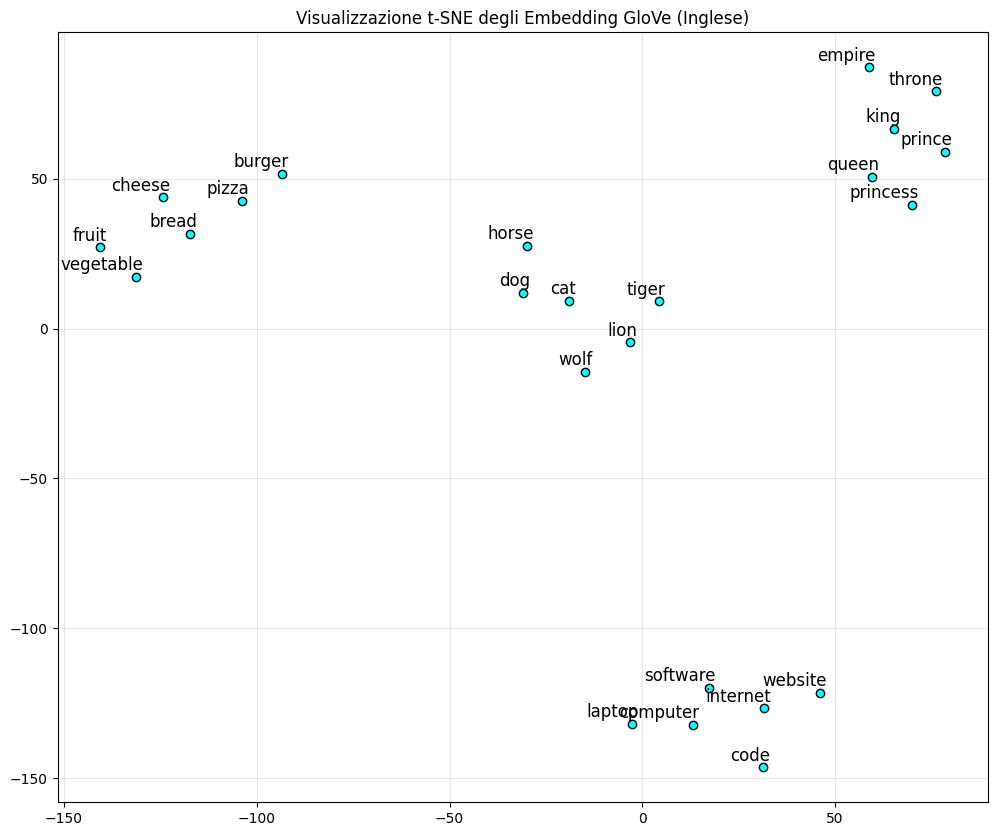

In [48]:
plt.figure(figsize=(12, 10))

# Disegniamo i punti
plt.scatter(low_dim_vectors[:, 0], low_dim_vectors[:, 1], edgecolors='k', c='cyan')

# Aggiungiamo le etichette
for i, label in enumerate(labels):
    plt.annotate(label,
                 xy=(low_dim_vectors[i, 0], low_dim_vectors[i, 1]),
                 xytext=(5, 2),
                 textcoords='offset points',
                 ha='right',
                 va='bottom',
                 fontsize=12)

plt.title("Visualizzazione t-SNE degli Embedding GloVe (Inglese)")
plt.grid(True, alpha=0.3)
plt.show()